# Plotting Time Series Models

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob

In [2]:
# set folder with data
path = '../results/'
# get all files in the folder
all_files = glob.glob(path + "*.csv")

In [3]:
# filter the files that contain "covid"
covid_files = [f for f in all_files if 'covid' in f]
# filter the files that contain "epidemics"
epidemics_files = [f for f in all_files if 'epidemics' in f]

In [4]:
# get the original data
df_covid = pd.read_csv('../Data/silver/covid_data_weekly.csv')  

In [5]:
df_covid.head()

,country,date,new_cases,cases
0,Brazil,2020-01-20,0,0
1,Brazil,2020-01-27,0,0
2,Brazil,2020-02-03,0,0
3,Brazil,2020-02-10,0,0
4,Brazil,2020-02-17,0,0


In [6]:
nrow_dict = {}
for country in df_covid['country'].unique():
    df_temp = df_covid[df_covid['country'] == country]
    nrow_dict[country] = len(df_temp)

In [7]:
nrow_dict

{'Brazil': 164,
 'Chile': 164,
 'Colombia': 164,
 'Dominican Republic': 164,
 'Germany': 164,
 'Italy': 164,
 'Mexico': 164,
 'Panama': 164,
 'US': 164,
 'Uruguay': 164}

In [8]:
from functools import reduce

# -------------------------------------------------------------------
# 1.  Load raw CSVs
# -------------------------------------------------------------------
df_dengue    = pd.read_csv('../Data/silver/dengue_no_split.csv')
df_zika      = pd.read_csv('../Data/silver/zika.csv').drop(columns=['Unnamed: 0'])
df_chic      = pd.read_csv('../Data/silver/chicunguya.csv').drop(columns=['Unnamed: 0'])
df_varicela  = pd.read_csv('../Data/silver/varicela.csv')

# -------------------------------------------------------------------
# 2.  Helper that:  (i) parses DATE  (ii) builds cumulative + t-1 series
# -------------------------------------------------------------------
def prep(df: pd.DataFrame, prefix: str) -> pd.DataFrame:
    df = df.copy()
    df['DATE'] = pd.to_datetime(df['DATE'])
    df = df.sort_values('DATE')

    # cumulative sum of new weekly cases
    df[f'cum_{prefix}'] = df['Casos'].cumsum()

    # keep only the useful columns
    return df[['DATE', f'cum_{prefix}']]

# -------------------------------------------------------------------
# 3.  Prepare each disease frame
# -------------------------------------------------------------------
dengue   = prep(df_dengue,   'dengue')
zika     = prep(df_zika,     'zika')
chik     = prep(df_chic,     'chik')
varicela = prep(df_varicela, 'var')

# -------------------------------------------------------------------
# 4.  Outer-merge on DATE → aligns differing timelines, fills gaps with NaN
# -------------------------------------------------------------------
df_epidemics = reduce(
    lambda left, right: pd.merge(left, right, on='DATE', how='outer'),
    [dengue, zika, chik, varicela]
).sort_values('DATE').set_index('DATE')
df_epidemics.reset_index(inplace=True)
df_epidemics.rename(columns={'DATE': 'date',
                             'cum_dengue':'dengue',
                             'cum_zika':'zika',
                             'cum_chik':'chik',
                             'cum_var': 'var'}, inplace=True)
df_epidemics


,date,dengue,zika,chik,var
0,2007-01-01,315,NaN,NaN,250.0
1,2007-01-08,551,NaN,NaN,557.0
2,2007-01-15,803,NaN,NaN,858.0
3,2007-01-22,1108,NaN,NaN,1124.0
4,2007-01-29,1468,NaN,NaN,1481.0
...,...,...,...,...,...
890,2023-11-27,663526,NaN,78139.0,1201321.0
891,2023-12-04,666895,NaN,78140.0,1201709.0
892,2023-12-11,670341,76165.0,78141.0,1202139.0
893,2023-12-18,673653,76167.0,78143.0,1202483.0


# Wrangle

## Covid

In [9]:
df_covid.tail()

,country,date,new_cases,cases
1635,Uruguay,2023-02-06,555,1033265
1636,Uruguay,2023-02-13,501,1033766
1637,Uruguay,2023-02-20,280,1034046
1638,Uruguay,2023-02-27,257,1034303
1639,Uruguay,2023-03-06,0,1034303


In [10]:
df_covid.head()

,country,date,new_cases,cases
0,Brazil,2020-01-20,0,0
1,Brazil,2020-01-27,0,0
2,Brazil,2020-02-03,0,0
3,Brazil,2020-02-10,0,0
4,Brazil,2020-02-17,0,0


In [11]:
dict_n_rows = {}
# count observations by country
for country in df_covid['country']:
    df_temp = df_covid[df_covid['country'] == country]
    dict_n_rows[country] = len(df_temp)

dict_n_rows

{'Brazil': 164,
 'Chile': 164,
 'Colombia': 164,
 'Dominican Republic': 164,
 'Germany': 164,
 'Italy': 164,
 'Mexico': 164,
 'Panama': 164,
 'US': 164,
 'Uruguay': 164}

In [12]:
# ----------------------------------------------------------
# 1.  Make sure date is datetime & records are chronological
# ----------------------------------------------------------
df_covid['date'] = pd.to_datetime(df_covid['date'])
df_covid = df_covid.sort_values('date')

# ----------------------------------------------------------
# 2.  Pivot: rows = date, columns = country, values = cases
#     (all countries have the same number of observations)
# ----------------------------------------------------------
wide = (
    df_covid
      .pivot(index='date', columns='country', values='cases')
      .sort_index()                       # chronological index
)

# ----------------------------------------------------------
# 3.  Mark the first 80 % rows as TRAIN and the last 20 % as TEST
# ----------------------------------------------------------
split_point = int(len(wide) * 0.8)        # row where the 80/20 cut happens

wide['set'] = np.where(
    np.arange(len(wide)) < split_point,   # row-position test
    'train',
    'test'
)

# ----------------------------------------------------------
# 4.  (Optional) quick sanity check
# ----------------------------------------------------------
print(wide['set'].value_counts(normalize=True))
print(wide.head())


set
train    0.79878
test     0.20122
Name: proportion, dtype: float64
country     Brazil  Chile  Colombia  Dominican Republic  Germany  Italy  \
date                                                                      
2020-01-20       0      0         0                   0        0      0   
2020-01-27       0      0         0                   0       10      2   
2020-02-03       0      0         0                   0       14      3   
2020-02-10       0      0         0                   0       16      3   
2020-02-17       0      2         0                   0       16    155   

country     Mexico  Panama  US  Uruguay    set  
date                                            
2020-01-20       0       0   4        0  train  
2020-01-27       0       0   7        0  train  
2020-02-03       0       0  11        0  train  
2020-02-10       0       0  13        0  train  
2020-02-17       0       0  15        0  train  


In [13]:
wide.tail()

country,Brazil,Chile,Colombia,Dominican Republic,Germany,Italy,Mexico,Panama,US,Uruguay,set
date,,,,,,,,,,,
2023-02-06,36932830,5138732,6355637,660412,37907312,25519067,7400848,1030214,102862878,1033265,test
2023-02-13,36987682,5149301,6356468,660492,38002114,25547414,7429778,1030658,103136076,1033766,test
2023-02-20,37020531,5163316,6357173,660533,38111063,25576852,7450992,1031014,103382762,1034046,test
2023-02-27,37081209,5180329,6358232,660705,38210851,25603510,7470653,1031273,103646974,1034303,test
2023-03-06,37076053,5192286,6359093,660790,38249060,25603510,7483444,1031731,103802701,1034303,test


In [14]:
df_covid_w = wide.copy().reset_index()

## Epidemics

In [15]:
# For each column in df_epidemics except 'date', create a new train/test split column.
# If the column contains NaNs, only the non-NaN entries are split by 80/20.
# The new column will be named "<original_column>_split".

for col in df_epidemics.columns:
    if col == 'date':
        continue
    series = df_epidemics[col]
    non_na = series.dropna()
    n = len(non_na)
    split_i = int(n * 0.8)
    split_labels = ['train'] * split_i + ['test'] * (n - split_i)
    
    # Initialize new split column with NaNs
    split_col = [np.nan] * len(series)
    
    # Get the indices of non-na values in order
    non_na_indices = non_na.index.tolist()
    for pos, row_idx in enumerate(non_na_indices):
        split_col[row_idx] = split_labels[pos]
    
    df_epidemics[col + '_split'] = split_col

df_epidemics

,date,dengue,zika,chik,var,dengue_split,zika_split,chik_split,var_split
0,2007-01-01,315,NaN,NaN,250.0,train,NaN,NaN,train
1,2007-01-08,551,NaN,NaN,557.0,train,NaN,NaN,train
2,2007-01-15,803,NaN,NaN,858.0,train,NaN,NaN,train
3,2007-01-22,1108,NaN,NaN,1124.0,train,NaN,NaN,train
4,2007-01-29,1468,NaN,NaN,1481.0,train,NaN,NaN,train
...,...,...,...,...,...,...,...,...,...
890,2023-11-27,663526,NaN,78139.0,1201321.0,test,NaN,test,test
891,2023-12-04,666895,NaN,78140.0,1201709.0,test,NaN,test,test
892,2023-12-11,670341,76165.0,78141.0,1202139.0,test,test,test,test
893,2023-12-18,673653,76167.0,78143.0,1202483.0,test,test,test,test


# Plots

# Target Variable

## Covid

### Cases

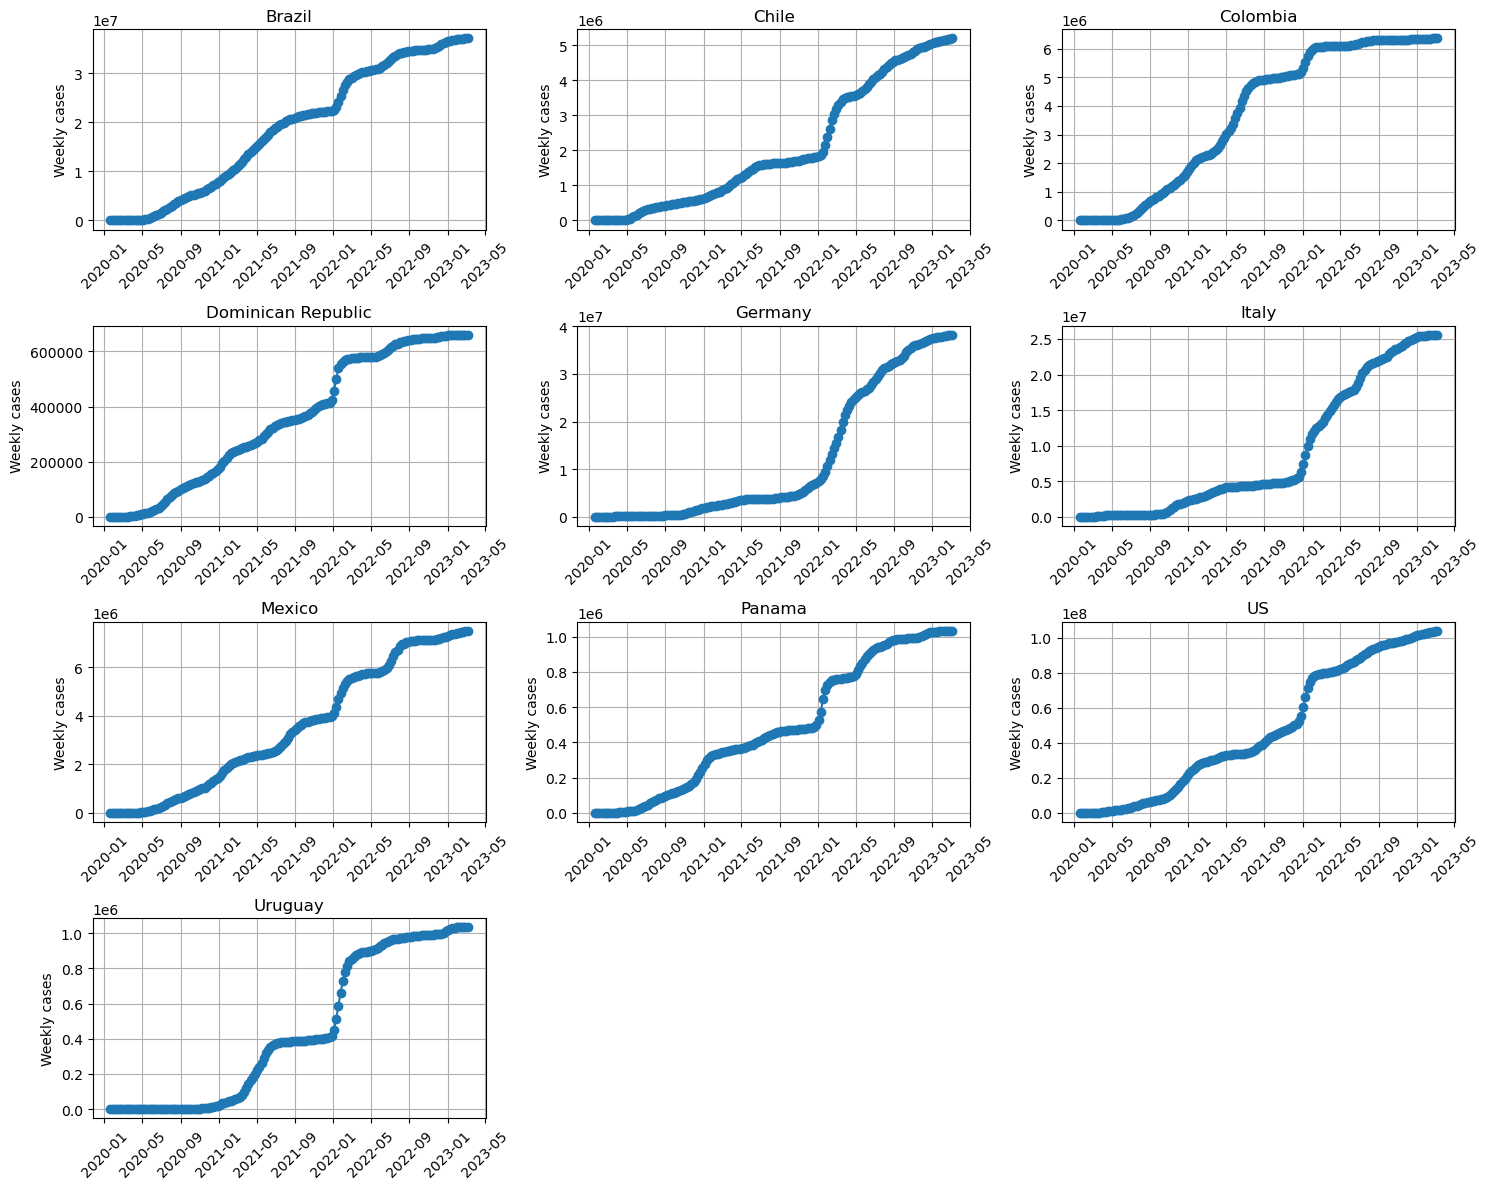

In [16]:
# 1) Prepare the DataFrame
df_covid_w['date'] = pd.to_datetime(df_covid_w['date'])
df_covid_w = df_covid_w.sort_values('date')

# Identify country columns
non_country = ['date', 'set'] if 'set' in df_covid_w.columns else ['date']
countries = [c for c in df_covid_w.columns if c not in non_country]

# 2) Set up the subplot grid
n_countries = len(countries)
ncols = 3
nrows = int(np.ceil(n_countries / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 3*nrows), sharex=False)
axes = axes.flatten()

# 3) Plot each country’s time series
for ax, country in zip(axes, countries):
    ax.plot(df_covid_w['date'], df_covid_w[country], marker='o', linestyle='-')
    ax.set_title(country)
    ax.set_ylabel('Weekly cases')
    ax.grid(True)
    # rotate date labels
    ax.tick_params(axis='x', rotation=45)

# 4) Remove any unused axes
for ax in axes[n_countries:]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()


In [17]:
import os

# 1) Ensure the output directory exists
output_dir = '../latex_plots'
os.makedirs(output_dir, exist_ok=True)

# 2) Save current figure as PDF
fig.savefig(
    os.path.join(output_dir, 'covid_cases_by_country.pdf'),
    format='pdf',
    bbox_inches='tight'
)

### New Cases

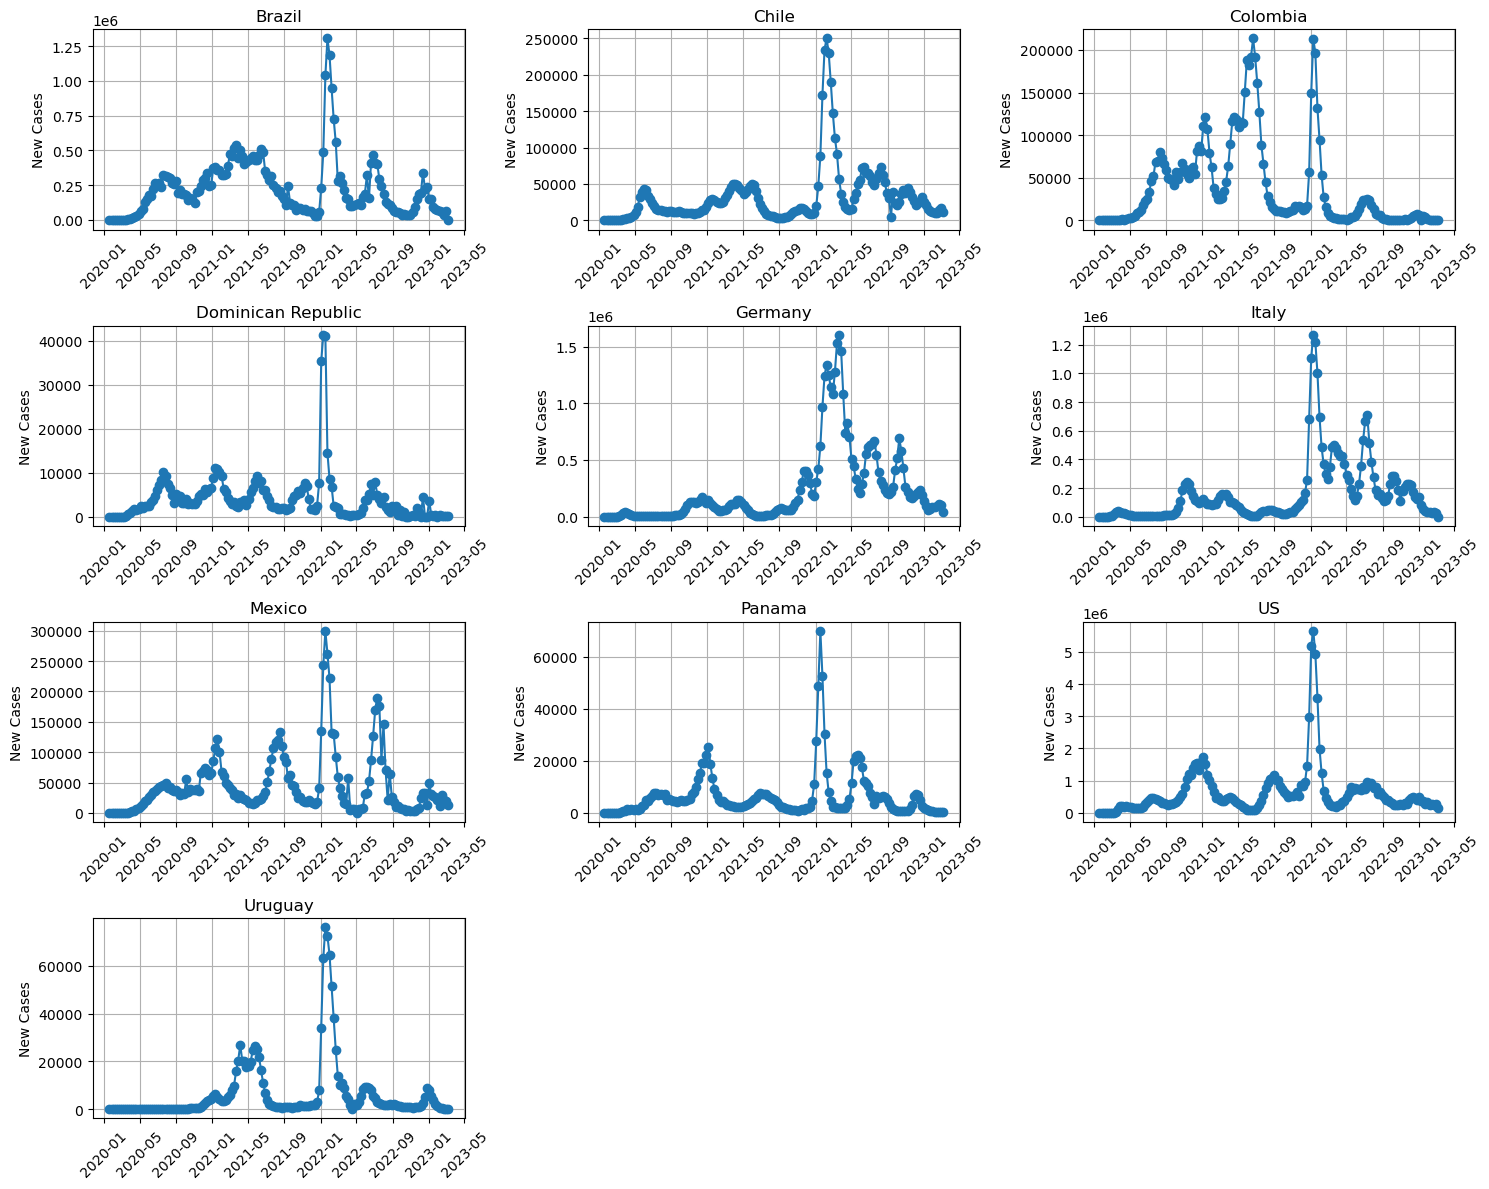

In [18]:
# 1) Convert 'date' column to datetime
df_covid['date'] = pd.to_datetime(df_covid['date'])

# 2) Pivot to wide format for plotting 'cases'
df_wide_n = df_covid.pivot(index='date', columns='country', values='new_cases')

# 3) Setup subplot grid (3 columns)
countries = df_wide_n.columns.tolist()
n_countries = len(countries)
ncols = 3
nrows = int(np.ceil(n_countries / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3 * nrows), sharex=False)
axes = axes.flatten()

# 4) Plot each country
for ax, country in zip(axes, countries):
    ax.plot(df_wide_n.index, df_wide_n[country], marker='o', linestyle='-')
    ax.set_title(country)
    ax.set_ylabel('New Cases')
    ax.grid(True)
    ax.tick_params(axis='x', rotation=45)

# 5) Remove unused subplots
for ax in axes[n_countries:]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()


In [19]:
# 2) Save current figure as PDF
fig.savefig(
    os.path.join(output_dir, 'covid_new_cases_by_country.pdf'),
    format='pdf',
    bbox_inches='tight')

### Results

### Cases

In [20]:
df_epidemics.columns

Index(['date', 'dengue', 'zika', 'chik', 'var', 'dengue_split', 'zika_split',
       'chik_split', 'var_split'],
      dtype='object')

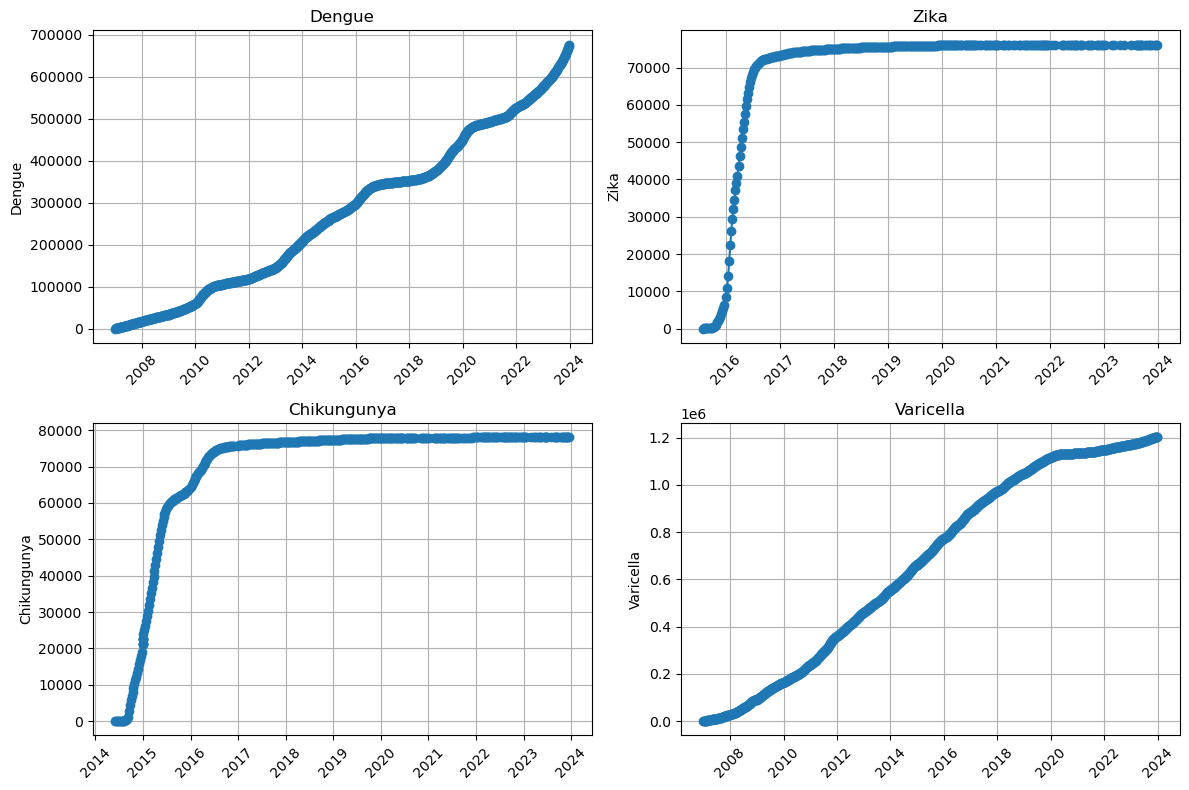

In [21]:
# 1) Make sure 'date' is datetime
df_epidemics['date'] = pd.to_datetime(df_epidemics['date'])

# 2) Specify the columns to plot and their human-readable names
variables = ['dengue', 'zika', 'chik', 'var']
names_dict = {
    'dengue': 'Dengue',
    'zika': 'Zika',
    'chik': 'Chikungunya',
    'var': 'Varicella'
}

# 3) Configure a 2×2 subplot grid
nvars = len(variables)
ncols = 2
nrows = int(np.ceil(nvars / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows), sharex=False)
axes = axes.flatten()

# 4) Plot each series, dropping NaNs so each subplot has its own date range
for ax, var in zip(axes, variables):
    series = df_epidemics[['date', var]].dropna()
    ax.plot(series['date'], series[var], marker='o', linestyle='-')
    pretty_name = names_dict.get(var, var.capitalize())
    ax.set_title(pretty_name)
    ax.set_ylabel(pretty_name)
    ax.grid(True)
    ax.tick_params(axis='x', rotation=45)

# 5) Remove any unused subplots (if fewer than 4 variables)
for ax in axes[nvars:]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()


In [22]:
# 2) Save current figure as PDF
fig.savefig(
    os.path.join(output_dir, 'cases_by_epidemic.pdf'),
    format='pdf',
    bbox_inches='tight')

## New Cases

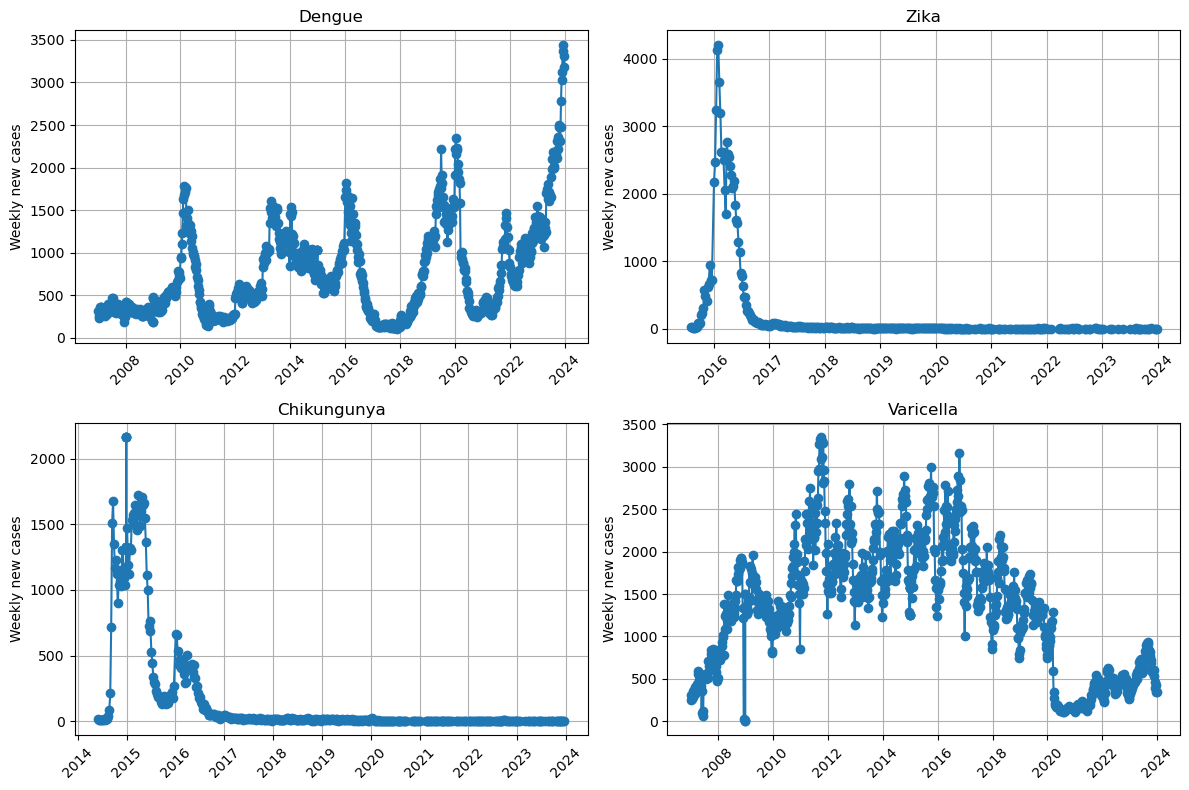

In [23]:

# -------------------------------------------------------------------
# 1.  Load raw CSVs
# -------------------------------------------------------------------
df_dengue    = pd.read_csv('../Data/silver/dengue_no_split.csv')
df_zika      = pd.read_csv('../Data/silver/zika.csv').drop(columns=['Unnamed: 0'])
df_chic      = pd.read_csv('../Data/silver/chicunguya.csv').drop(columns=['Unnamed: 0'])
df_varicela  = pd.read_csv('../Data/silver/varicela.csv')

# -------------------------------------------------------------------
# 2.  Helper to parse DATE and keep raw weekly cases
# -------------------------------------------------------------------
def prep_raw(df: pd.DataFrame, prefix: str) -> pd.DataFrame:
    df = df.copy()
    df['DATE'] = pd.to_datetime(df['DATE'])
    df = df.sort_values('DATE')
    # keep only the weekly cases column
    return df[['DATE', 'Casos']].rename(columns={'Casos': prefix})

# -------------------------------------------------------------------
# 3.  Prepare each disease frame (raw weekly cases)
# -------------------------------------------------------------------
dengue_raw   = prep_raw(df_dengue,   'dengue')
zika_raw     = prep_raw(df_zika,     'zika')
chik_raw     = prep_raw(df_chic,     'chik')
var_raw      = prep_raw(df_varicela, 'var')

# -------------------------------------------------------------------
# 4.  Outer-merge on DATE → aligns timelines, NaNs where missing
# -------------------------------------------------------------------
df_epidemics_raw = reduce(
    lambda left, right: pd.merge(left, right, on='DATE', how='outer'),
    [dengue_raw, zika_raw, chik_raw, var_raw]
).sort_values('DATE').rename(columns={'DATE': 'date'})

# -------------------------------------------------------------------
# 5.  Plot the four series in a 2×2 grid
# -------------------------------------------------------------------
variables = ['dengue', 'zika', 'chik', 'var']
names_dict = {
    'dengue': 'Dengue',
    'zika':    'Zika',
    'chik':    'Chikungunya',
    'var':     'Varicella'
}

nvars = len(variables)
ncols = 2
nrows = int(np.ceil(nvars / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 4*nrows), sharex=False)
axes = axes.flatten()

for ax, var in zip(axes, variables):
    tmp = df_epidemics_raw[['date', var]].dropna()
    ax.plot(tmp['date'], tmp[var], marker='o', linestyle='-')
    pretty = names_dict[var]
    ax.set_title(pretty)
    ax.set_ylabel('Weekly new cases')
    ax.grid(True)
    ax.tick_params(axis='x', rotation=45)

# remove any unused subplots (if fewer than 4)
for ax in axes[nvars:]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()


In [24]:
# 2) Save current figure as PDF
fig.savefig(
    os.path.join(output_dir, 'new_cases_by_epidemic.pdf'),
    format='pdf',
    bbox_inches='tight')

# Covariates

## COVID

In [114]:
df_covid = pd.read_csv('../Data/gold/covid_multivariate_w_2.csv')
df_covid.head()

,date,country,new_cases,cases,co,no2,o3,pm10,pm25,so2,population,google_physician,google_hospital,google_pharmacy,google_symptom,Mean_distance_avg_14day_movavg,StringencyIndex_Average,pop_vaccinated
0,2020-03-23,Chile,1558,10261,5.828571,5.242857,10.619048,28.350649,37.952381,3.773810,19331414,30,8,9,32,19.456667,69.844286,0.0
1,2020-03-30,Chile,2420,24909,5.978571,6.516667,13.771429,38.922078,50.726190,4.035714,19331414,27,7,10,28,12.998571,75.930000,0.0
2,2020-04-06,Chile,2987,43938,6.235714,6.992857,12.733333,43.142857,66.071429,3.840476,19331414,28,7,9,25,11.041429,75.930000,0.0
3,2020-04-13,Chile,3304,65523,7.383333,8.771429,11.707143,43.233766,69.059524,4.076190,19331414,28,6,9,21,10.270000,75.930000,0.0
4,2020-04-20,Chile,4054,90640,6.742857,6.788095,11.769048,38.662338,63.321429,3.661905,19331414,24,6,9,21,10.878571,75.930000,0.0


In [115]:
df_covid.rename(columns = {'Mean_distance_avg_14day_movavg': 'mean_dist_14d',
                            'StringencyIndex_Average': 'stringency_avg'}, inplace=True)

In [ ]:
df_covid_col = df_covid[df_covid['country'] == 'Colombia'].copy()
df_covid_col['date'] = pd.to_datetime(df_covid_col['date'])
df_covid_col['cases_t_1'] = df_covid_col['cases'].shift(-1)
df_covid_col.dropna(inplace=True)
# convert date to numeric
df_covid_col['date_num'] = df_covid_col['date'].map(pd.Timestamp.timestamp)
# make a copy to get some plots 
df_covid_col_plot = df_covid_col.copy()
df_covid_col.drop(columns=['country', 'date'], inplace=True)


In [117]:
df_covid_col.dropna(inplace=True)
df_covid_col

,new_cases,cases,co,no2,o3,pm10,pm25,so2,population,google_physician,google_hospital,google_pharmacy,google_symptom,mean_dist_14d,stringency_avg,pop_vaccinated,cases_t_1,date_num
145,471,3465,6.007143,7.164286,18.142857,48.857143,118.285714,0.742857,50326931,28,10,6,44,7.531667,78.171429,0.000000,8088.0,1.584922e+09
146,783,8088,5.992857,6.228571,13.057143,25.214286,63.214286,0.628571,50326931,31,8,6,40,4.344286,87.960000,0.000000,15594.0,1.585526e+09
147,1291,15594,4.335714,4.700000,11.757143,15.214286,37.285714,0.614286,50326931,40,8,6,38,2.705714,87.960000,0.000000,23021.0,1.586131e+09
148,1016,23021,5.028571,7.000000,12.092857,31.571429,74.785714,0.642857,50326931,27,8,5,31,1.977143,84.788571,0.000000,32445.0,1.586736e+09
149,1587,32445,5.207143,7.192857,9.607143,23.071429,53.500000,0.442857,50326931,24,7,5,29,2.207143,85.451429,0.000000,46219.0,1.587341e+09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284,0,44188599,12.914286,12.471429,3.957143,32.571429,61.928571,0.542857,51443283,22,7,4,24,15.328571,19.440000,70.988571,44192949.0,1.668989e+09
285,1450,44192949,10.078571,11.414286,4.650000,30.500000,58.642857,0.685714,51443283,12,6,5,24,15.254286,19.440000,71.040000,44213264.0,1.669594e+09
286,2903,44213264,6.214286,11.164286,4.492857,32.642857,63.428571,0.514286,51443283,13,11,5,27,15.428571,19.440000,71.040000,44240154.0,1.670198e+09
287,5271,44240154,6.285714,10.728571,4.085714,35.642857,60.857143,0.500000,51443283,12,11,4,25,15.705714,19.440000,71.061429,44276091.0,1.670803e+09


In [118]:
# reorder the columns
df_covid_col = df_covid_col[['cases_t_1', 'cases', 'new_cases', 'date_num',  'co', 'no2', 'o3', 'pm10', 'pm25', 'so2',
       'population', 'google_physician', 'google_hospital', 'google_pharmacy',
       'google_symptom', 'mean_dist_14d', 'stringency_avg', 'pop_vaccinated']]

In [119]:
# create correlation matrix
df_corr = df_covid_col.corr()
df_corr

,cases_t_1,cases,new_cases,date_num,co,no2,o3,pm10,pm25,so2,population,google_physician,google_hospital,google_pharmacy,google_symptom,mean_dist_14d,stringency_avg,pop_vaccinated
cases_t_1,1.000000,0.999770,-0.175266,0.967937,0.748759,0.622313,-0.479767,0.164756,0.170045,0.388996,0.940859,-0.796076,0.379548,0.091702,-0.370347,0.909091,-0.914774,0.921559
cases,0.999770,1.000000,-0.195990,0.969380,0.746058,0.626420,-0.475338,0.165169,0.173845,0.387853,0.940270,-0.799139,0.380379,0.090897,-0.378801,0.908765,-0.918072,0.926326
new_cases,-0.175266,-0.195990,1.000000,-0.254570,-0.016530,-0.309435,-0.090572,-0.046767,-0.207463,-0.037843,-0.145540,0.299822,-0.118330,0.002350,0.382129,-0.158637,0.328664,-0.395218
date_num,0.967937,0.969380,-0.254570,1.000000,0.699970,0.644836,-0.489947,0.177064,0.177393,0.351784,0.937783,-0.809781,0.428577,0.062028,-0.368802,0.901218,-0.947188,0.942683
co,0.748759,0.746058,-0.016530,0.699970,1.000000,0.661111,-0.476054,0.222472,0.209274,0.394066,0.730722,-0.484507,0.130855,-0.026158,-0.375797,0.693348,-0.618599,0.569351
no2,0.622313,0.626420,-0.309435,0.644836,0.661111,1.000000,-0.405176,0.362869,0.319373,0.434210,0.570897,-0.520883,0.147596,-0.135394,-0.477459,0.637607,-0.609540,0.587049
o3,-0.479767,-0.475338,-0.090572,-0.489947,-0.476054,-0.405176,1.000000,0.022404,0.213996,-0.202761,-0.409760,0.438150,0.054392,0.251855,0.247060,-0.436307,0.461408,-0.399354
pm10,0.164756,0.165169,-0.046767,0.177064,0.222472,0.362869,0.022404,1.000000,0.896560,0.494582,0.144286,-0.210433,0.043719,-0.105711,-0.080402,0.308792,-0.132798,0.153437
pm25,0.170045,0.173845,-0.207463,0.177393,0.209274,0.319373,0.213996,0.896560,1.000000,0.485044,0.181006,-0.231781,0.150077,0.037468,-0.056385,0.285080,-0.142548,0.208482
so2,0.388996,0.387853,-0.037843,0.351784,0.394066,0.434210,-0.202761,0.494582,0.485044,1.000000,0.382823,-0.373236,0.098010,0.065214,-0.071382,0.461949,-0.280659,0.372717


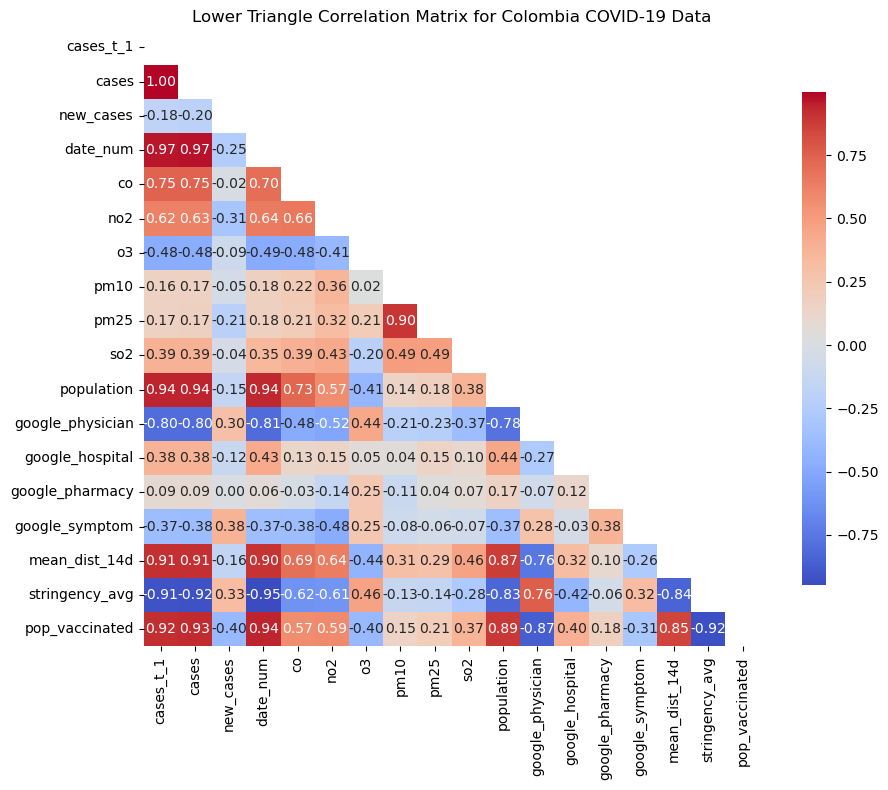

In [120]:
# create a mask for the upper triangle
mask = np.triu(np.ones_like(df_corr, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    df_corr, 
    mask=mask, 
    annot=True, 
    cmap='coolwarm', 
    fmt='.2f', 
    square=True, 
    cbar_kws={"shrink": .8}, 
    ax=ax
)
ax.set_title('Lower Triangle Correlation Matrix for Colombia COVID-19 Data')
fig.tight_layout()

# Save the figure
fig.savefig(
    os.path.join(output_dir, 'correlation_colombia_covid.pdf'),
    format='pdf',
    bbox_inches='tight')

plt.show()

In [121]:
# sort the df_corr by the first column and keep only the column
df_corr = df_corr.sort_values(by='cases_t_1', ascending=False)
df_corr = df_corr[['cases_t_1']].drop('cases_t_1', axis=0)
df_corr = df_corr.reset_index()
df_corr = df_corr.rename(columns={'cases_t_1': 'correlation'})
df_corr



,index,correlation
0,cases,0.999770
1,date_num,0.967937
2,population,0.940859
3,pop_vaccinated,0.921559
4,mean_dist_14d,0.909091
5,co,0.748759
6,no2,0.622313
7,so2,0.388996
8,google_hospital,0.379548
9,pm25,0.170045


C:\Users\danie\AppData\Local\Temp\ipykernel_24640\1617388553.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='correlation', y='index', data=df_corr, palette='coolwarm', ax=ax)


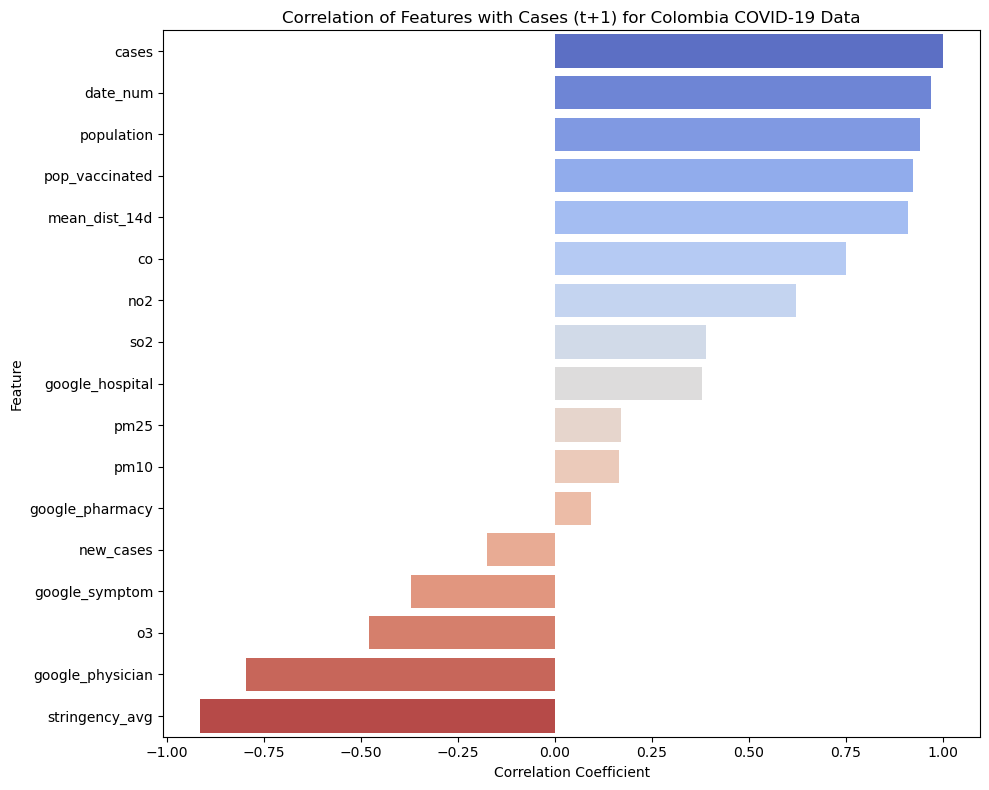

In [122]:
# barplot the correlation values
fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(x='correlation', y='index', data=df_corr, palette='coolwarm', ax=ax)
ax.set_title('Correlation of Features with Cases (t+1) for Colombia COVID-19 Data')
ax.set_xlabel('Correlation Coefficient')
ax.set_ylabel('Feature')
fig.tight_layout()

# Save before or after plt.show(), both work — but best to save first
fig.savefig(
    os.path.join(output_dir, 'correlation_colombia_covid_bars.pdf'),
    format='pdf',
    bbox_inches='tight')

plt.show()

In [123]:
# get the top 5 correlated features in absolute value
df_corr['abs_correlation'] = df_corr['correlation'].abs()
df_corr = df_corr.sort_values(by='abs_correlation', ascending=False)
df_corr

,index,correlation,abs_correlation
0,cases,0.999770,0.999770
1,date_num,0.967937,0.967937
2,population,0.940859,0.940859
3,pop_vaccinated,0.921559,0.921559
16,stringency_avg,-0.914774,0.914774
4,mean_dist_14d,0.909091,0.909091
15,google_physician,-0.796076,0.796076
5,co,0.748759,0.748759
6,no2,0.622313,0.622313
14,o3,-0.479767,0.479767


In [124]:
df_corr['index'][0:6].tolist()

['cases',
 'date_num',
 'population',
 'pop_vaccinated',
 'stringency_avg',
 'mean_dist_14d']

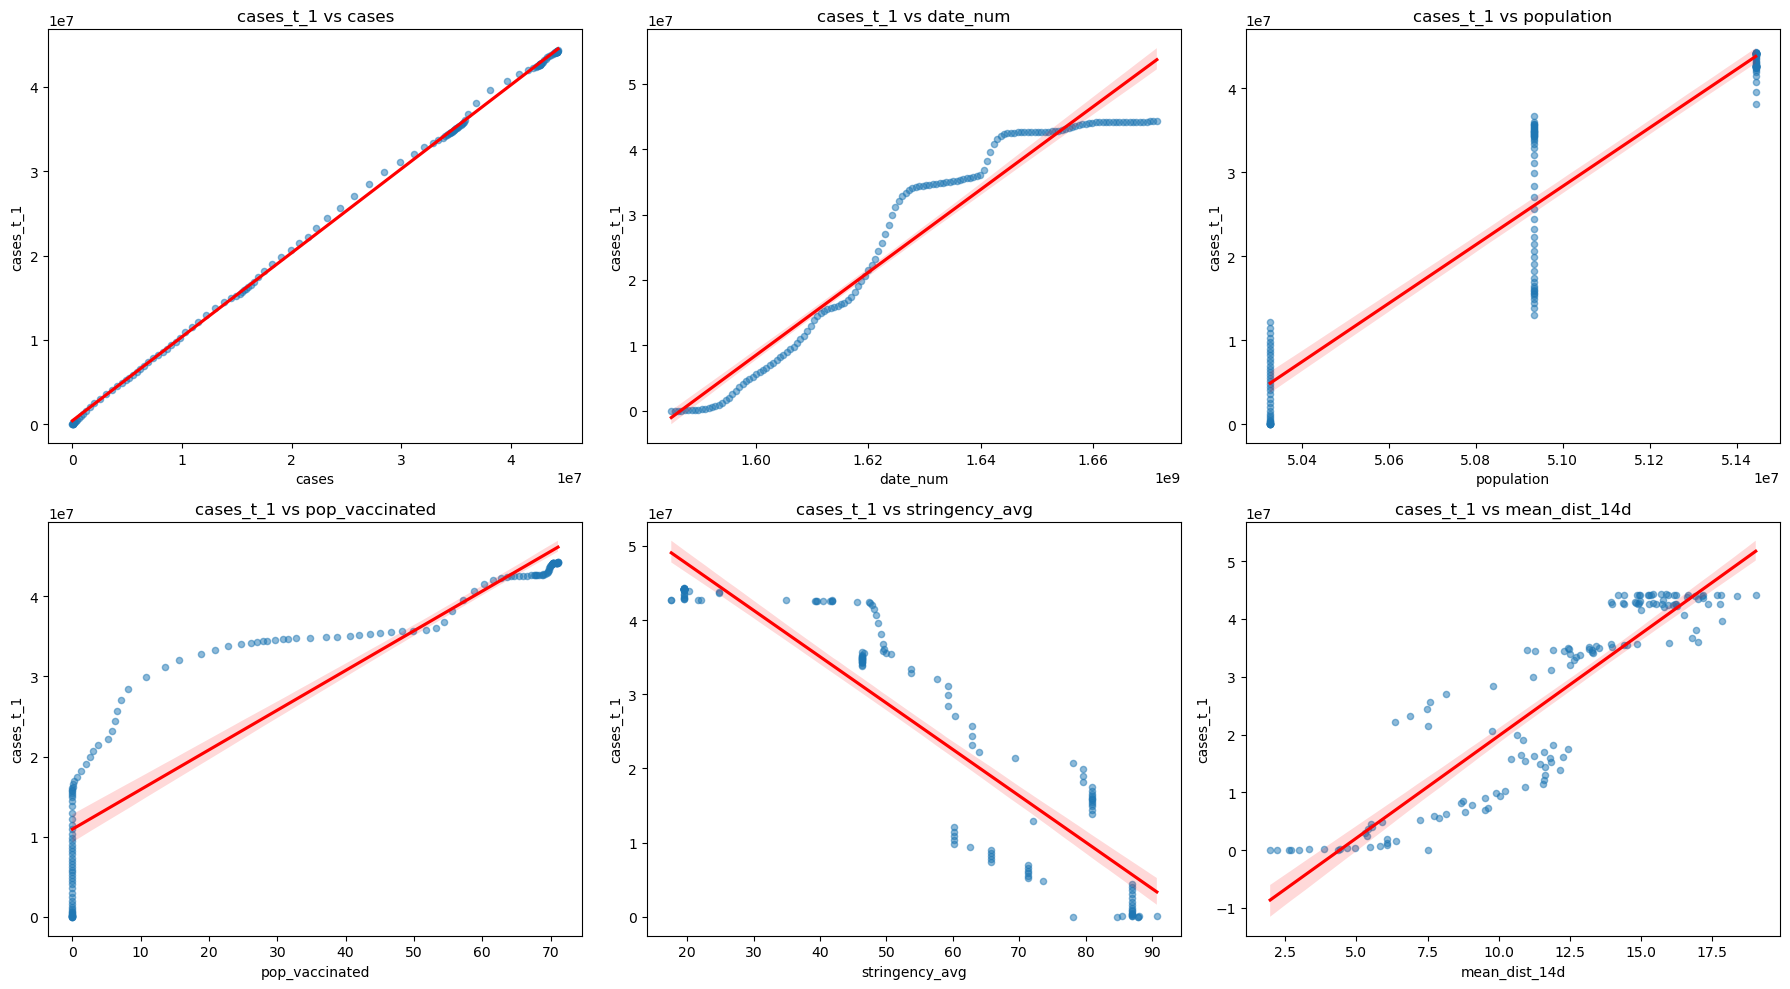

In [125]:
variables_to_plot = ['cases', 'date_num','population', 'pop_vaccinated', 'stringency_avg', 'mean_dist_14d']
target_variable = 'cases_t_1'

# Create 2x3 grid of subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# Loop through variables and plot
for i, var in enumerate(variables_to_plot):
    sns.regplot(
        x=var,
        y=target_variable,
        data=df_covid_col,
        ax=axes[i],
        scatter_kws={"s": 20, "alpha": 0.5},
        line_kws={"color": "red"}
    )
    axes[i].set_title(f'{target_variable} vs {var}')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel(target_variable)

# Turn off the unused subplot
for j in range(len(variables_to_plot), len(axes)):
    axes[j].axis('off')

# Adjust layout
plt.tight_layout()

# Save the figure as PDF
fig.savefig(
    os.path.join(output_dir, 'regplots_covid_colombia.pdf'),
    format='pdf',
    bbox_inches='tight'
)

# Show the figure
plt.show()

Plot mobility and stringency in time series

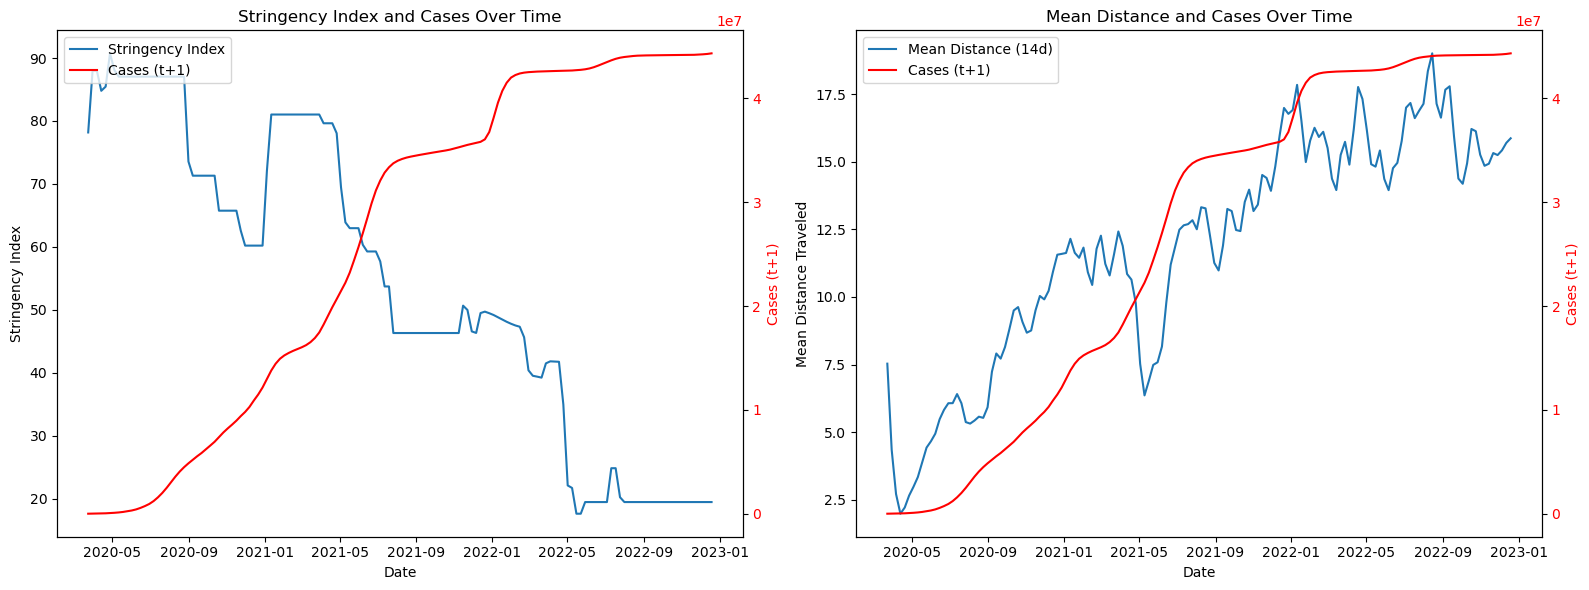

In [130]:

# Set up 1x2 subplot grid
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: stringency_avg and cases_t_1 ---
ax1 = axes[0]
sns.lineplot(
    x='date',
    y='stringency_avg',
    data=df_covid_col_plot,
    ax=ax1,
    label='Stringency Index'
)
ax1.set_title('Stringency Index and Cases Over Time')
ax1.set_xlabel('Date')
ax1.set_ylabel('Stringency Index')
ax1.tick_params(axis='y')

# Secondary y-axis for cases_t_1
ax1b = ax1.twinx()
line_cases1 = sns.lineplot(
    x='date',
    y='cases_t_1',
    data=df_covid_col_plot,
    ax=ax1b,
    color='red'
)
ax1b.set_ylabel('Cases (t+1)', color='red')
ax1b.tick_params(axis='y', labelcolor='red')

# Combine legends, adding 'Cases (t+1)' manually
lines1, labels1 = ax1.get_legend_handles_labels()
lines1.append(line_cases1.lines[0])
labels1.append('Cases (t+1)')
ax1.legend(lines1, labels1, loc='upper left')

# --- Plot 2: mean_dist_14d and cases_t_1 ---
ax2 = axes[1]
sns.lineplot(
    x='date',
    y='mean_dist_14d',
    data=df_covid_col_plot,
    ax=ax2,
    label='Mean Distance (14d)'
)
ax2.set_title('Mean Distance and Cases Over Time')
ax2.set_xlabel('Date')
ax2.set_ylabel('Mean Distance Traveled')
ax2.tick_params(axis='y')

# Secondary y-axis for cases_t_1
ax2b = ax2.twinx()
line_cases2 = sns.lineplot(
    x='date',
    y='cases_t_1',
    data=df_covid_col_plot,
    ax=ax2b,
    color='red'
)
ax2b.set_ylabel('Cases (t+1)', color='red')
ax2b.tick_params(axis='y', labelcolor='red')

# Combine legends, adding 'Cases (t+1)' manually
lines2, labels2 = ax2.get_legend_handles_labels()
lines2.append(line_cases2.lines[0])
labels2.append('Cases (t+1)')
ax2.legend(lines2, labels2, loc='upper left')

# Layout and save
plt.tight_layout()

fig.savefig(
    os.path.join(output_dir, 'stringency_distance_cases_dualaxis.pdf'),
    format='pdf',
    bbox_inches='tight'
)

plt.show()


## Epidemics

In [135]:
df_epidemics = pd.read_csv('../Data/gold/epidemics.csv')
df_epidemics.head()

,week,dengue,zika,chik,var,date,tavg,tmin,tmax,prcp,...,google_pharmacy,google_symptom,co,dew,humidity,no2,o3,pm10,pm25,so2
0,2020-03-23,949,3.0,1.0,351.0,2020-03-23,20.003080,14.529673,25.878470,1.866561,...,6,44,6.007143,11.964286,82.078571,7.164286,18.142857,48.857143,118.285714,0.742857
1,2020-03-30,1006,1.0,4.0,275.0,2020-03-30,20.310320,15.607637,25.801951,4.628407,...,6,40,5.992857,12.285714,79.671429,6.228571,13.057143,25.214286,63.214286,0.628571
2,2020-04-06,931,3.0,2.0,212.0,2020-04-06,20.567575,15.800335,25.874548,3.028124,...,6,38,4.335714,12.678571,79.557143,4.700000,11.757143,15.214286,37.285714,0.614286
3,2020-04-13,883,1.0,0.0,188.0,2020-04-13,19.564572,14.112981,25.608096,2.240946,...,5,31,5.028571,11.714286,82.707143,7.000000,12.092857,31.571429,74.785714,0.642857
4,2020-04-20,879,3.0,3.0,195.0,2020-04-20,19.833153,14.608703,25.966335,4.637722,...,5,29,5.207143,11.928571,83.142857,7.192857,9.607143,23.071429,53.500000,0.442857


In [136]:
df_epidemics.rename(columns = {'mob_index': 'mean_dist_14d'}, inplace=True)

In [137]:
df_epidemics.columns

Index(['week', 'dengue', 'zika', 'chik', 'var', 'date', 'tavg', 'tmin', 'tmax',
       'prcp', 'wdir', 'wspd', 'pres', 'mean_dist_14d', 'google_physician',
       'google_hospital', 'google_pharmacy', 'google_symptom', 'co', 'dew',
       'humidity', 'no2', 'o3', 'pm10', 'pm25', 'so2'],
      dtype='object')

In [138]:
df_dengue = df_epidemics[['date', 'dengue',
                          'tavg', 'tmin', 'tmax', 'prcp', 'wdir', 'wspd', 'pres','humidity','dew', 
                          'co', 'no2', 'o3', 'pm10', 'pm25', 'so2',
                          'mean_dist_14d',
                          'google_physician', 'google_hospital', 'google_pharmacy', 'google_symptom']].copy()

In [139]:
# convert date to numeric
df_dengue['date'] = pd.to_datetime(df_dengue['date'])
df_dengue['date_num'] = df_dengue['date'].map(pd.Timestamp.timestamp)
# get shifted value of dengue
df_dengue['dengue_t_1'] = df_dengue['dengue'].shift(-1)
df_dengue.dropna(inplace=True)
# copy before dropping cols
df_dengue_plot = df_dengue.copy()
# reorder the columns
df_dengue = df_dengue[['dengue_t_1', 'dengue', 'date_num', 'tavg', 'tmin', 'tmax', 'prcp', 'wdir', 'wspd', 'pres','humidity','dew',
                        'co', 'no2', 'o3', 'pm10', 'pm25', 'so2',
                        'mean_dist_14d',
                        'google_physician', 'google_hospital', 'google_pharmacy', 'google_symptom']] 

In [142]:
df_corr_dengue = df_dengue.corr()
df_corr_dengue

,dengue_t_1,dengue,date_num,tavg,tmin,tmax,prcp,wdir,wspd,pres,...,no2,o3,pm10,pm25,so2,mean_dist_14d,google_physician,google_hospital,google_pharmacy,google_symptom
dengue_t_1,1.000000,0.989368,0.837015,0.340090,0.064986,0.294539,-0.009417,0.017761,0.168293,0.455425,...,0.194634,0.065458,0.130922,0.044147,0.022850,0.666034,-0.412733,0.760969,0.445202,-0.363046
dengue,0.989368,1.000000,0.831110,0.347783,0.068934,0.302676,-0.008569,0.014654,0.176686,0.443737,...,0.193116,0.074004,0.139526,0.052989,0.024721,0.661654,-0.419106,0.755779,0.436098,-0.348542
date_num,0.837015,0.831110,1.000000,0.135870,0.004434,0.040911,0.089466,0.101533,0.124463,0.720707,...,0.424029,-0.125261,0.190455,0.097818,0.143655,0.850882,-0.629801,0.790493,0.478001,-0.435490
tavg,0.340090,0.347783,0.135870,1.000000,0.523426,0.783342,-0.142797,-0.533277,0.578189,-0.168769,...,-0.386752,0.493564,-0.317064,-0.319326,-0.210161,0.015618,0.059811,0.367976,0.441694,0.099885
tmin,0.064986,0.068934,0.004434,0.523426,1.000000,0.058420,0.117923,-0.171547,-0.004315,-0.060683,...,-0.189397,-0.014383,-0.434916,-0.321682,-0.206720,-0.035066,0.035603,0.082383,0.178253,0.036615
tmax,0.294539,0.302676,0.040911,0.783342,0.058420,1.000000,-0.201434,-0.436776,0.515343,-0.256038,...,-0.305283,0.526684,-0.022331,-0.082917,0.018166,-0.020159,0.062903,0.238696,0.317339,0.148245
prcp,-0.009417,-0.008569,0.089466,-0.142797,0.117923,-0.201434,1.000000,0.170134,-0.325525,-0.043952,...,0.191757,-0.190386,0.017208,-0.006664,-0.056112,0.067449,-0.027486,0.057582,0.002998,-0.027263
wdir,0.017761,0.014654,0.101533,-0.533277,-0.171547,-0.436776,0.170134,1.000000,-0.506884,0.150535,...,0.361843,-0.356561,0.476660,0.518586,0.321179,0.155866,-0.283973,-0.093605,-0.202053,-0.180830
wspd,0.168293,0.176686,0.124463,0.578189,-0.004315,0.515343,-0.325525,-0.506884,1.000000,-0.041690,...,-0.227333,0.627478,-0.071517,-0.066116,-0.167558,0.088002,0.111926,0.344047,0.361483,0.045255
pres,0.455425,0.443737,0.720707,-0.168769,-0.060683,-0.256038,-0.043952,0.150535,-0.041690,1.000000,...,0.373686,-0.286108,0.124939,0.088349,0.238578,0.680666,-0.591687,0.397622,0.268437,-0.316249


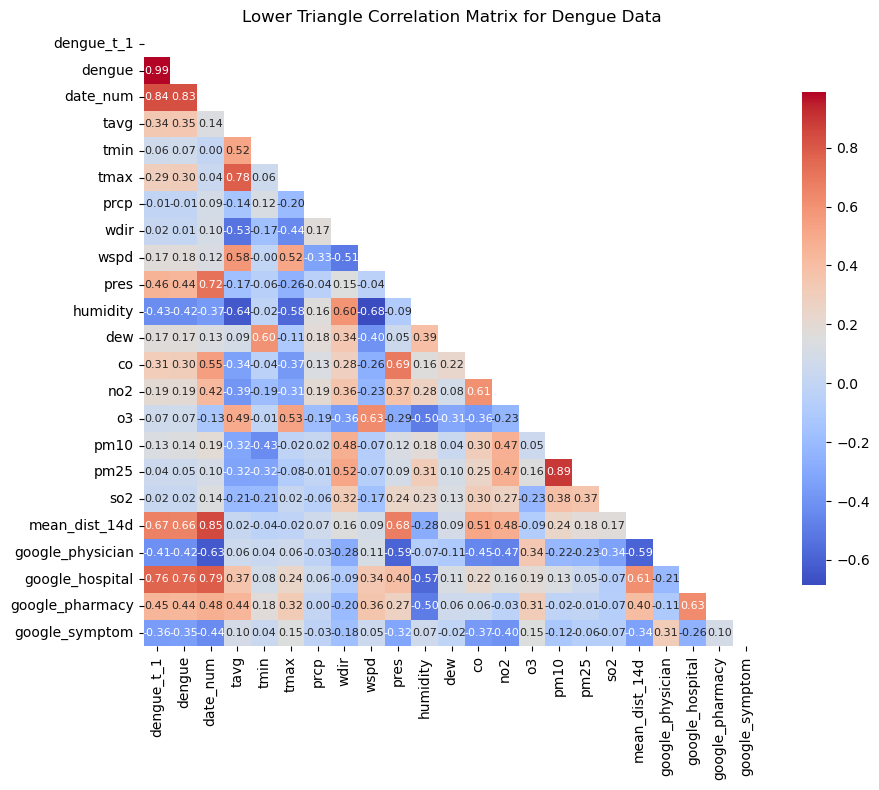

In [144]:
# create a mask for the upper triangle
mask = np.triu(np.ones_like(df_corr_dengue, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    df_corr_dengue, 
    mask=mask, 
    annot=True, 
    annot_kws={"size": 8},  # Smaller font size for annotations
    cmap='coolwarm', 
    fmt='.2f', 
    square=True, 
    cbar_kws={"shrink": .8}, 
    ax=ax
)
ax.set_title('Lower Triangle Correlation Matrix for Dengue Data')
fig.tight_layout()

fig.savefig(
    os.path.join(output_dir, 'correlation_dengue.pdf'),
    format='pdf',
    bbox_inches='tight'
)

plt.show()


In [145]:
# sort the df_corr by the first column and keep only the column
df_corr_dengue = df_corr_dengue.sort_values(by='dengue_t_1', ascending=False)
df_corr_dengue = df_corr_dengue[['dengue_t_1']].drop('dengue_t_1', axis=0)
df_corr_dengue = df_corr_dengue.reset_index()
df_corr_dengue = df_corr_dengue.rename(columns={'dengue_t_1': 'correlation'})
df_corr_dengue

,index,correlation
0,dengue,0.989368
1,date_num,0.837015
2,google_hospital,0.760969
3,mean_dist_14d,0.666034
4,pres,0.455425
5,google_pharmacy,0.445202
6,tavg,0.340090
7,co,0.308699
8,tmax,0.294539
9,no2,0.194634


C:\Users\danie\AppData\Local\Temp\ipykernel_24640\1267714516.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='correlation', y='index', data=df_corr_dengue, palette='coolwarm', ax=ax)


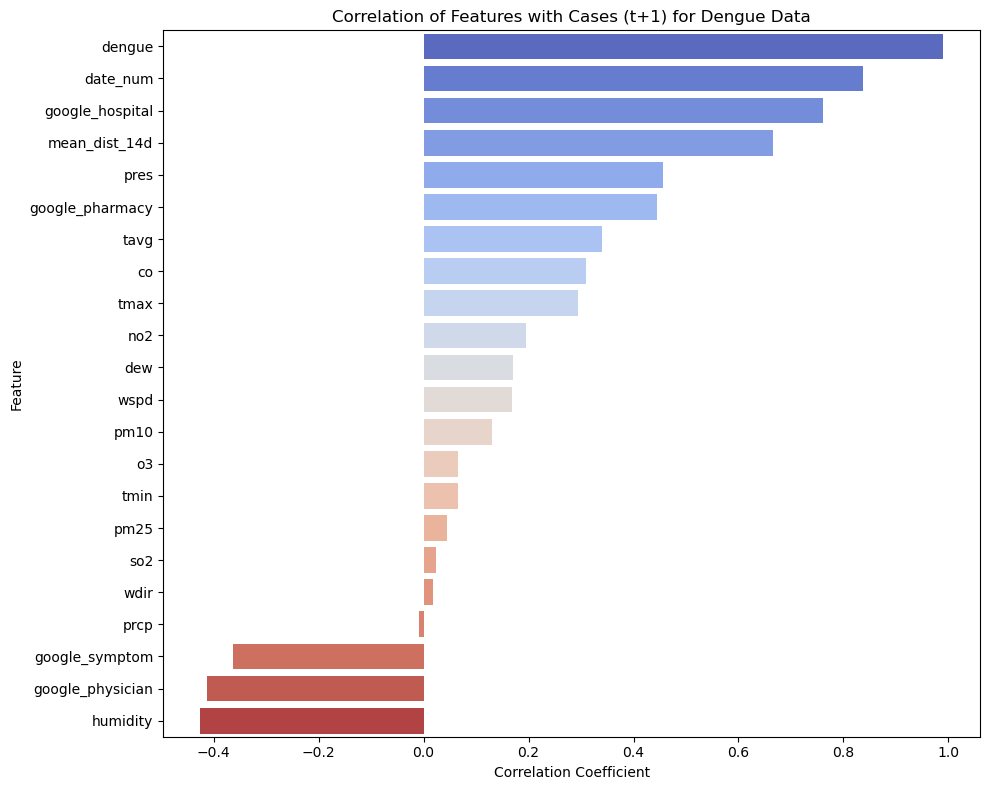

In [146]:
# barplot the correlation values
fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(x='correlation', y='index', data=df_corr_dengue, palette='coolwarm', ax=ax)
ax.set_title('Correlation of Features with Cases (t+1) for Dengue Data')
ax.set_xlabel('Correlation Coefficient')
ax.set_ylabel('Feature')
fig.tight_layout()

# Save before or after plt.show(), both work — but best to save first
fig.savefig(
    os.path.join(output_dir, 'correlation_dengue_bars.pdf'),
    format='pdf',
    bbox_inches='tight')

plt.show()

In [147]:
# get the top 5 correlated features in absolute value
df_corr_dengue['abs_correlation'] = df_corr_dengue['correlation'].abs()
df_corr_dengue = df_corr_dengue.sort_values(by='abs_correlation', ascending=False)
df_corr_dengue

,index,correlation,abs_correlation
0,dengue,0.989368,0.989368
1,date_num,0.837015,0.837015
2,google_hospital,0.760969,0.760969
3,mean_dist_14d,0.666034,0.666034
4,pres,0.455425,0.455425
5,google_pharmacy,0.445202,0.445202
21,humidity,-0.425323,0.425323
20,google_physician,-0.412733,0.412733
19,google_symptom,-0.363046,0.363046
6,tavg,0.340090,0.340090


In [153]:
df_corr_dengue['index'][0:7].tolist()

['dengue',
 'date_num',
 'google_hospital',
 'mean_dist_14d',
 'pres',
 'google_pharmacy',
 'humidity']

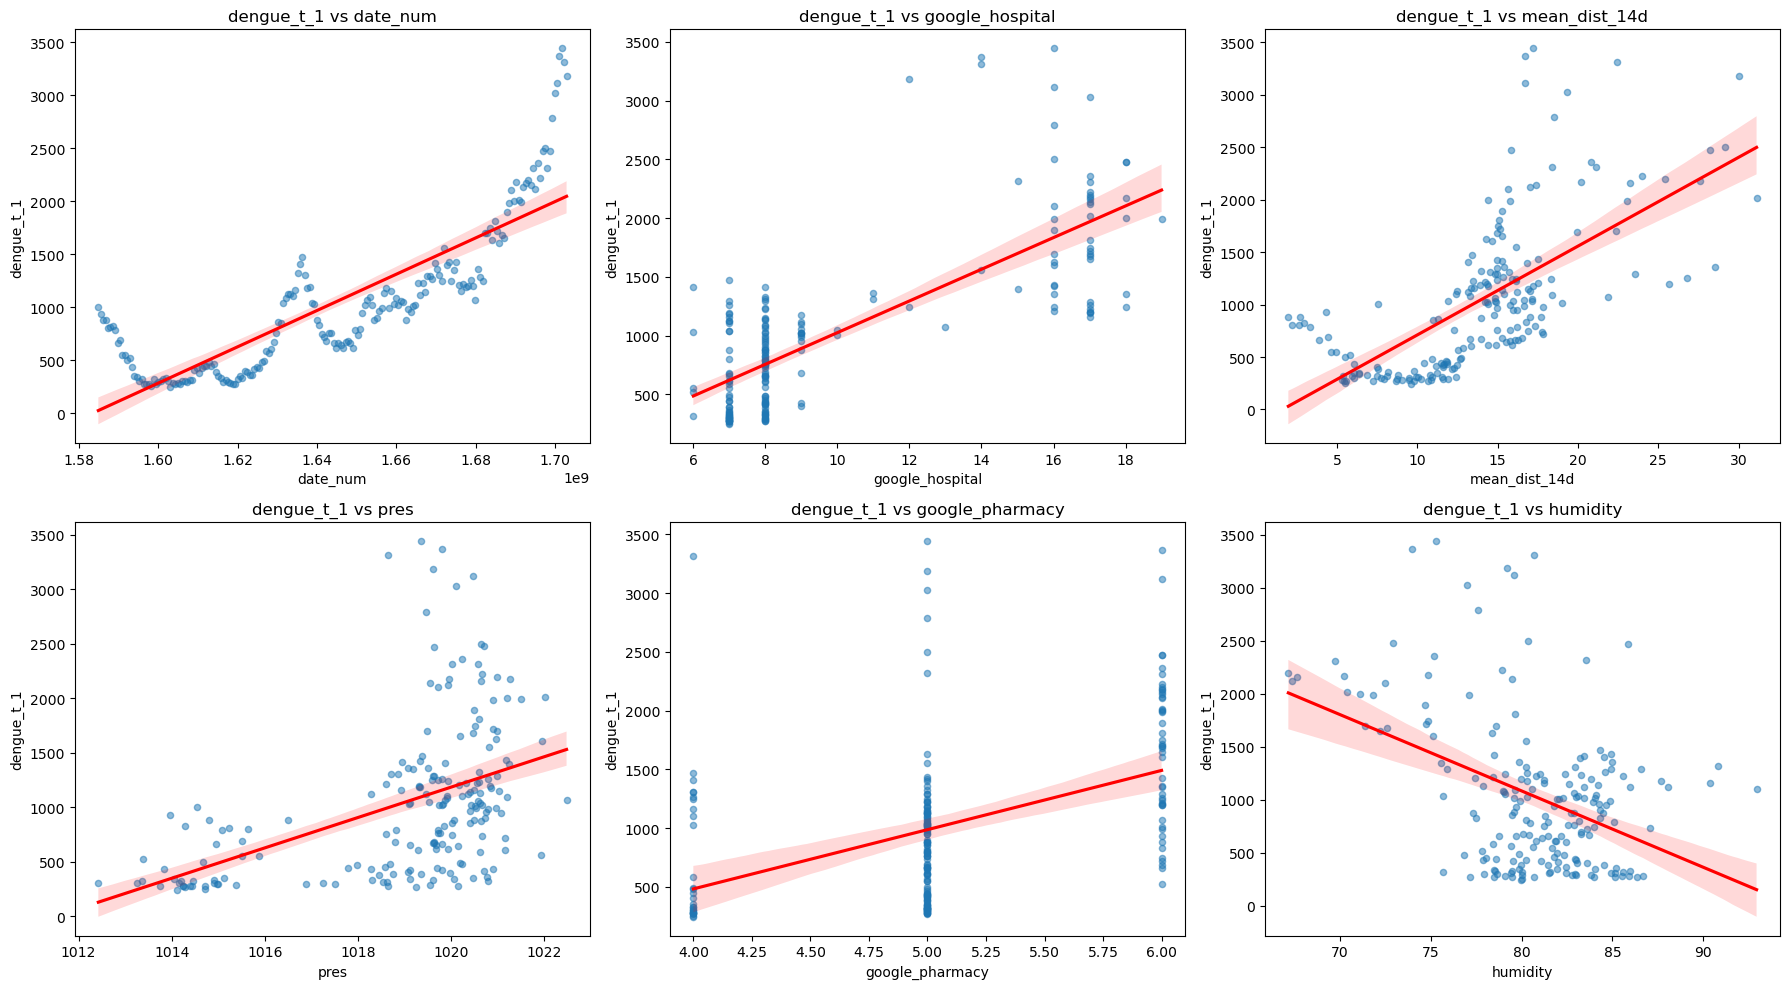

In [154]:
variables_to_plot = ['date_num', 'google_hospital', 'mean_dist_14d', 'pres', 'google_pharmacy', 'humidity']
target_variable = 'dengue_t_1'

# Create 2x3 grid of subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# Loop through variables and plot
for i, var in enumerate(variables_to_plot):
    sns.regplot(
        x=var,
        y=target_variable,
        data=df_dengue,
        ax=axes[i],
        scatter_kws={"s": 20, "alpha": 0.5},
        line_kws={"color": "red"}
    )
    axes[i].set_title(f'{target_variable} vs {var}')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel(target_variable)

# Turn off the unused subplot
for j in range(len(variables_to_plot), len(axes)):
    axes[j].axis('off')

# Adjust layout
plt.tight_layout()

# Save the figure as PDF
fig.savefig(
    os.path.join(output_dir, 'regplots_dengue.pdf'),
    format='pdf',
    bbox_inches='tight'
)

# Show the figure
plt.show()

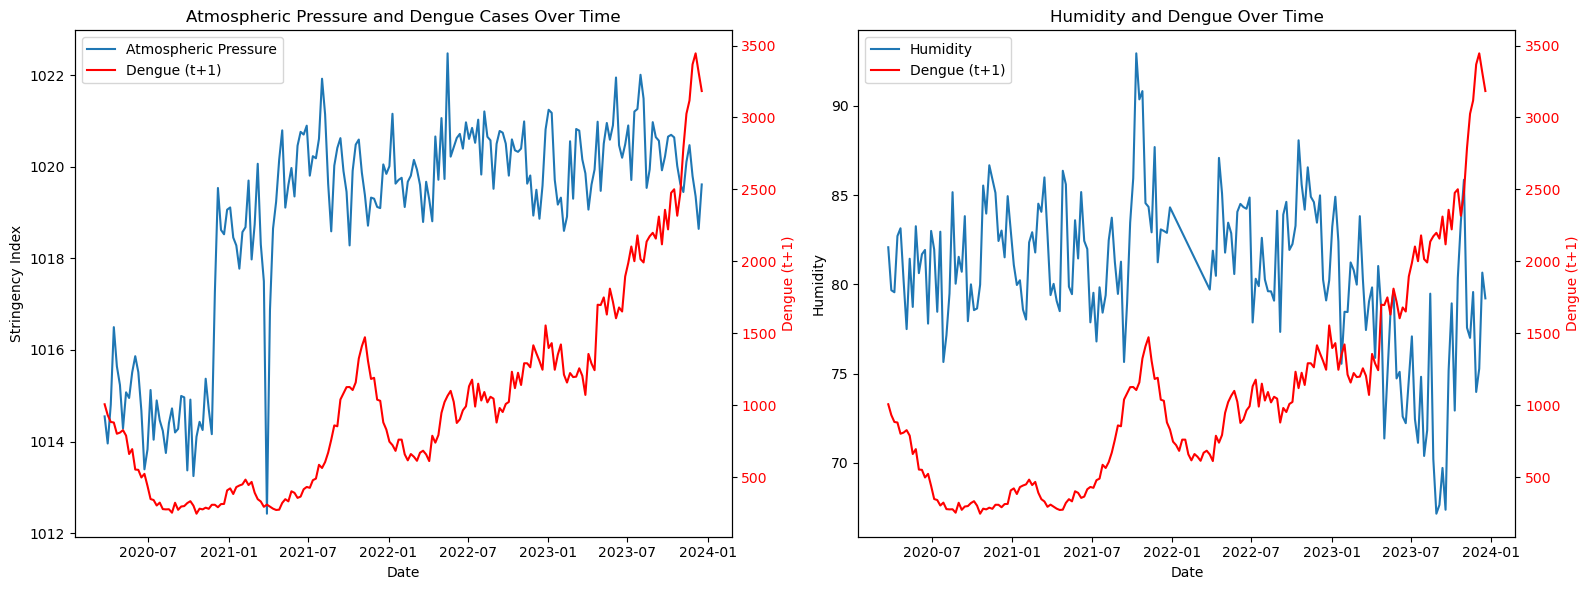

In [156]:
# Set up 1x2 subplot grid
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: stringency_avg and cases_t_1 ---
ax1 = axes[0]
sns.lineplot(
    x='date',
    y='pres',
    data=df_dengue_plot,
    ax=ax1,
    label='Atmospheric Pressure'
)
ax1.set_title('Atmospheric Pressure and Dengue Cases Over Time')
ax1.set_xlabel('Date')
ax1.set_ylabel('Stringency Index')
ax1.tick_params(axis='y')

# Secondary y-axis for cases_t_1
ax1b = ax1.twinx()
line_cases1 = sns.lineplot(
    x='date',
    y='dengue_t_1',
    data=df_dengue_plot,
    ax=ax1b,
    color='red'
)
ax1b.set_ylabel('Dengue (t+1)', color='red')
ax1b.tick_params(axis='y', labelcolor='red')

# Combine legends, adding 'Cases (t+1)' manually
lines1, labels1 = ax1.get_legend_handles_labels()
lines1.append(line_cases1.lines[0])
labels1.append('Dengue (t+1)')
ax1.legend(lines1, labels1, loc='upper left')

# --- Plot 2: mean_dist_14d and cases_t_1 ---
ax2 = axes[1]
sns.lineplot(
    x='date',
    y='humidity',
    data=df_dengue_plot,
    ax=ax2,
    label='Humidity'
)
ax2.set_title('Humidity and Dengue Over Time')
ax2.set_xlabel('Date')
ax2.set_ylabel('Humidity')
ax2.tick_params(axis='y')

# Secondary y-axis for cases_t_1
ax2b = ax2.twinx()
line_cases2 = sns.lineplot(
    x='date',
    y='dengue_t_1',
    data=df_dengue_plot,
    ax=ax2b,
    color='red'
)
ax2b.set_ylabel('Dengue (t+1)', color='red')
ax2b.tick_params(axis='y', labelcolor='red')

# Combine legends, adding 'Cases (t+1)' manually
lines2, labels2 = ax2.get_legend_handles_labels()
lines2.append(line_cases2.lines[0])
labels2.append('Dengue (t+1)')
ax2.legend(lines2, labels2, loc='upper left')

# Layout and save
plt.tight_layout()

fig.savefig(
    os.path.join(output_dir, 'pres_humidity_dengue_dualaxis.pdf'),
    format='pdf',
    bbox_inches='tight'
)

plt.show()
